# MAT File Visualization and Dimension Analysis

This notebook automatically searches for `.mat` files in the current directory, loads the first 3 files, summarizes variable shapes, and performs basic visualization.

In [4]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Compatible with different MAT versions
from scipy.io import loadmat

# Prefer the directory where this notebook is located
BASE_DIR = Path('/home/curry/Documents/NO4Jean')
if not BASE_DIR.exists():
    BASE_DIR = Path.cwd()

mat_files = sorted(BASE_DIR.glob('*.mat'))
print(f'Found {len(mat_files)} .mat files in {BASE_DIR}')
for i, f in enumerate(mat_files, 1):
    print(f'{i}. {f.name}')


def safe_loadmat(file_path):
    """Try scipy.io.loadmat first; if it fails, try h5py for v7.3 files."""
    try:
        return loadmat(file_path)
    except Exception as e:
        print(f'\n[Info] scipy failed to read {file_path.name}: {e}')
        try:
            import h5py
            data = {}
            with h5py.File(file_path, 'r') as f:
                for k in f.keys():
                    data[k] = np.array(f[k])
            return data
        except Exception as e2:
            print(f'[Error] h5py also failed: {e2}')
            return None







Found 3 .mat files in /home/curry/Documents/NO4Jean
1. params_and_kernels_17_04.mat
2. params_and_kernels_22_04.mat
3. params_and_kernels_23_04.mat


Loading: /home/curry/Documents/NO4Jean/params_and_kernels_17_04.mat
Total variables: 3

Variable Dimensions Summary:
--------------------------------------------------------------------------------
K_con                | Shape: (25, 2, 2, 2000)     | Dtype: float64         | Size: 200000
L_con                | Shape: (25, 2, 2, 2000)     | Dtype: float64         | Size: 200000
params_all           | Shape: (2000, 20)           | Dtype: float64         | Size: 40000

Individual Visualizations for Each Variable

[K_con] Shape: (25, 2, 2, 2000), Dtype: float64


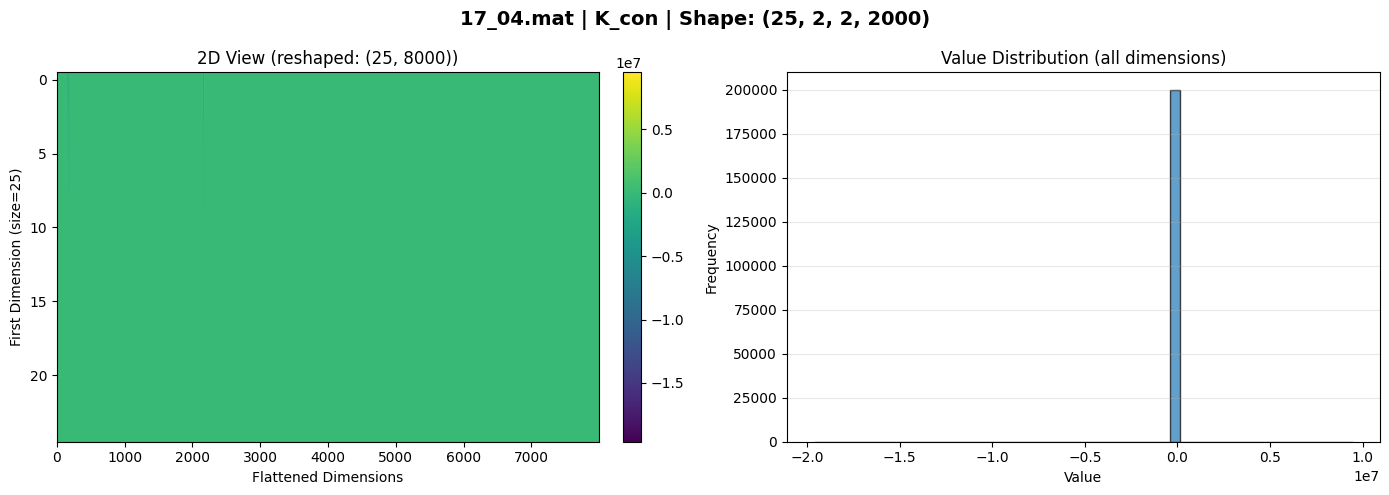


[L_con] Shape: (25, 2, 2, 2000), Dtype: float64


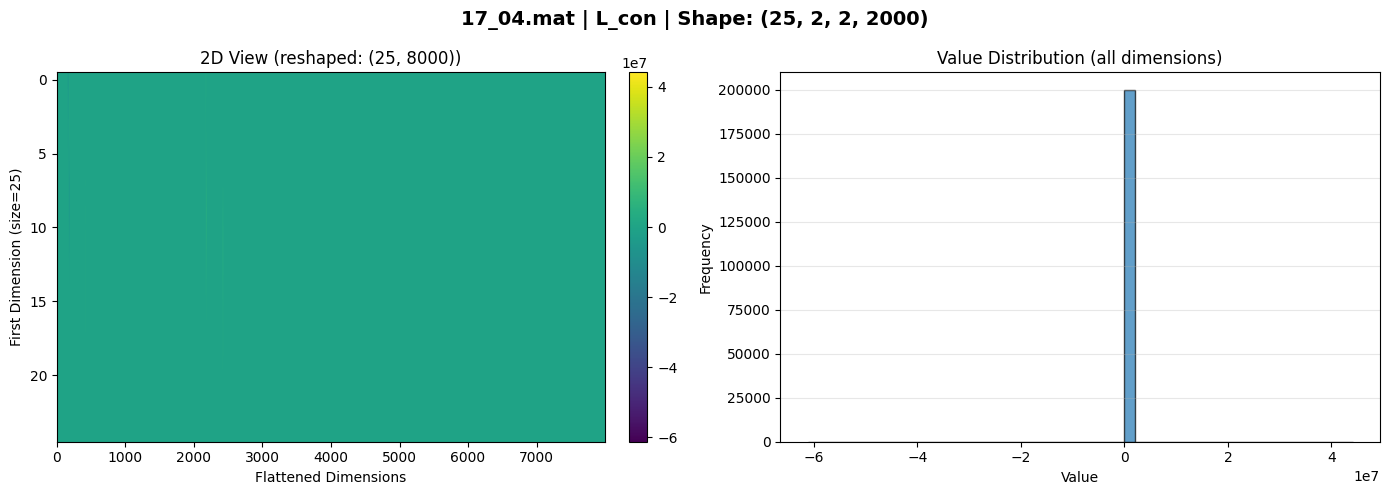


[params_all] Shape: (2000, 20), Dtype: float64


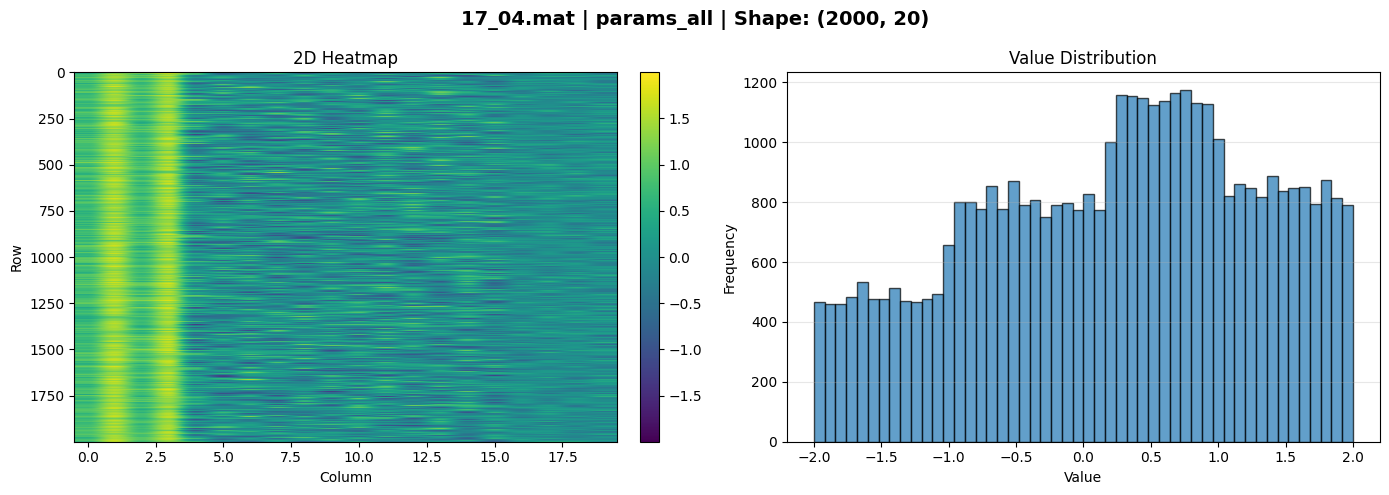


Analysis Complete!


In [5]:

# ========================================================================
# Detailed Analysis of params_and_kernels_17_04.mat
# ========================================================================

file_path = BASE_DIR / 'params_and_kernels_17_04.mat'
print(f'Loading: {file_path}')
print('=' * 80)

data_17_04 = safe_loadmat(file_path)

if data_17_04 is None:
    print('Failed to load the file.')
else:
    # Filter out meta variables
    user_vars = {k: v for k, v in data_17_04.items() if is_user_key(k)}
    
    print(f'Total variables: {len(user_vars)}')
    print('\nVariable Dimensions Summary:')
    print('-' * 80)
    
    for var_name, var_data in user_vars.items():
        var_array = np.array(var_data)
        print(f'{var_name:20s} | Shape: {str(var_array.shape):20s} | Dtype: {str(var_array.dtype):15s} | Size: {var_array.size}')
    
    print('\n' + '=' * 80)
    print('Individual Visualizations for Each Variable')
    print('=' * 80)
    
    # Visualize each numeric variable
    for var_name, var_data in user_vars.items():
        var_array = np.array(var_data)
        
        # Skip non-numeric variables
        if not numeric_array(var_data):
            print(f'\n[SKIP] {var_name}: Not a numeric array')
            continue
        
        print(f'\n[{var_name}] Shape: {var_array.shape}, Dtype: {var_array.dtype}')
        
        ndim = var_array.ndim
        
        if ndim == 1:
            # 1D visualization
            fig, axes = plt.subplots(1, 2, figsize=(14, 4))
            fig.suptitle(f'17_04.mat | {var_name} | Shape: {var_array.shape}', fontsize=14, fontweight='bold')
            
            # Line plot
            axes[0].plot(var_array, linewidth=1.5)
            axes[0].set_title('1D Line Plot')
            axes[0].set_xlabel('Index')
            axes[0].set_ylabel('Value')
            axes[0].grid(True, alpha=0.3)
            
            # Histogram
            flat = var_array[~np.isnan(var_array)] if np.issubdtype(var_array.dtype, np.floating) else var_array
            axes[1].hist(flat, bins=50, edgecolor='black', alpha=0.7)
            axes[1].set_title('Value Distribution')
            axes[1].set_xlabel('Value')
            axes[1].set_ylabel('Frequency')
            axes[1].grid(True, alpha=0.3, axis='y')
            
            plt.tight_layout()
            plt.show()
        
        elif ndim == 2:
            # 2D visualization
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            fig.suptitle(f'17_04.mat | {var_name} | Shape: {var_array.shape}', fontsize=14, fontweight='bold')
            
            # Heatmap
            im = axes[0].imshow(var_array, aspect='auto', cmap='viridis')
            axes[0].set_title('2D Heatmap')
            axes[0].set_xlabel('Column')
            axes[0].set_ylabel('Row')
            plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
            
            # Histogram
            flat = var_array.ravel()
            flat = flat[~np.isnan(flat)] if np.issubdtype(flat.dtype, np.floating) else flat
            axes[1].hist(flat, bins=50, edgecolor='black', alpha=0.7)
            axes[1].set_title('Value Distribution')
            axes[1].set_xlabel('Value')
            axes[1].set_ylabel('Frequency')
            axes[1].grid(True, alpha=0.3, axis='y')
            
            plt.tight_layout()
            plt.show()
        
        elif ndim >= 3:
            # Multi-dimensional visualization: reshape to 2D and show histogram
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            fig.suptitle(f'17_04.mat | {var_name} | Shape: {var_array.shape}', fontsize=14, fontweight='bold')
            
            # Reshape to 2D: keep first dimension, flatten rest
            reshaped_2d = var_array.reshape(var_array.shape[0], -1)
            im = axes[0].imshow(reshaped_2d, aspect='auto', cmap='viridis')
            axes[0].set_title(f'2D View (reshaped: {reshaped_2d.shape})')
            axes[0].set_xlabel('Flattened Dimensions')
            axes[0].set_ylabel(f'First Dimension (size={var_array.shape[0]})')
            plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
            
            # Histogram
            flat = var_array.ravel()
            flat = flat[~np.isnan(flat)] if np.issubdtype(flat.dtype, np.floating) else flat
            axes[1].hist(flat, bins=50, edgecolor='black', alpha=0.7)
            axes[1].set_title('Value Distribution (all dimensions)')
            axes[1].set_xlabel('Value')
            axes[1].set_ylabel('Frequency')
            axes[1].grid(True, alpha=0.3, axis='y')
            
            plt.tight_layout()
            plt.show()
    
    print('\n' + '=' * 80)
    print('Analysis Complete!')


In [14]:
data_17_04.keys()

dict_keys(['__header__', '__version__', '__globals__', 'K_con', 'L_con', 'params_all'])

In [12]:
data_17_04['K_con'][:,:,:,0].shape

(25, 2, 2)

In [11]:
data_17_04['L_con'][:,:,:,0]

array([[[ 0.25145504,  0.21505015],
        [ 0.45494927, -0.00982563]],

       [[ 0.2992961 ,  0.21510551],
        [ 0.4886119 ,  0.00227569]],

       [[ 0.34796515,  0.21511494],
        [ 0.5208904 ,  0.01456474]],

       [[ 0.39841821,  0.21508341],
        [ 0.55113075,  0.02644935]],

       [[ 0.45121653,  0.21502283],
        [ 0.57935861,  0.03798356]],

       [[ 0.50536642,  0.21490395],
        [ 0.60192971,  0.05076274]],

       [[ 0.56121558,  0.21470194],
        [ 0.62098253,  0.06385414]],

       [[ 0.61921538,  0.2143947 ],
        [ 0.63867525,  0.07631558]],

       [[ 0.68041007,  0.21408496],
        [ 0.47715758,  0.08754604]],

       [[ 0.74332911,  0.21384381],
        [ 0.46081019,  0.0992242 ]],

       [[ 0.80946717,  0.21370934],
        [ 0.44470025,  0.1105548 ]],

       [[ 0.87891477,  0.213615  ],
        [ 0.42907845,  0.12176578]],

       [[ 0.95171483,  0.2134947 ],
        [ 0.41393303,  0.13158175]],

       [[ 1.0281583 ,  0.21333921],
  

In [13]:
# ========================================================================
# Prepare training/test datasets for neural operator training
# ========================================================================

import numpy as np

# Inputs
X = np.asarray(data_17_04['params_all'], dtype=np.float32)

# Outputs: flatten K_con and L_con separately, then concatenate into a 200-dim vector
# Original shapes: K_con, L_con -> (25, 2, 2, 2000)
# We want one sample per last-axis index, so reshape to (2000, 100)
K_con = np.asarray(data_17_04['K_con'], dtype=np.float32).reshape(-1, data_17_04['K_con'].shape[-1]).T
L_con = np.asarray(data_17_04['L_con'], dtype=np.float32).reshape(-1, data_17_04['L_con'].shape[-1]).T
Y = np.concatenate([K_con, L_con], axis=1)

print('Input X shape:', X.shape)
print('K_con flattened shape:', K_con.shape)
print('L_con flattened shape:', L_con.shape)
print('Output Y shape:', Y.shape)

# Basic consistency checks
assert X.shape[0] == Y.shape[0], 'Input and output sample counts must match.'
assert Y.shape[1] == 200, 'Combined output should have 200 dimensions.'

# 8:2 train/test split with shuffling
rng = np.random.default_rng(42)
indices = rng.permutation(X.shape[0])
train_size = int(0.8 * X.shape[0])
train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train, Y_train = X[train_idx], Y[train_idx]
X_test, Y_test = X[test_idx], Y[test_idx]

print('\nTrain/Test Split:')
print('X_train:', X_train.shape, 'Y_train:', Y_train.shape)
print('X_test :', X_test.shape, 'Y_test :', Y_test.shape)

# Optional: bundle as dictionaries for later training code
train_data = {'X': X_train, 'Y': Y_train}
test_data = {'X': X_test, 'Y': Y_test}

print('\nReady for model training.')


Input X shape: (2000, 20)
K_con flattened shape: (2000, 100)
L_con flattened shape: (2000, 100)
Output Y shape: (2000, 200)

Train/Test Split:
X_train: (1600, 20) Y_train: (1600, 200)
X_test : (400, 20) Y_test : (400, 200)

Ready for model training.


===== 17_04 数据分布统计 =====
[K_con] shape=(2000, 100), dtype=float32
  min=-1.963051e+07, max=9.479154e+06, mean=-8.653570e+02, std=1.159740e+05
  p1=-2.108847e+01, p50=-9.859827e-03, p99=2.215337e+01
[L_con] shape=(2000, 100), dtype=float32
  min=-6.121987e+07, max=4.411331e+07, mean=5.807400e+02, std=4.413906e+05
  p1=-4.348512e+01, p50=-5.406291e-03, p99=3.892342e+01
[params_all] shape=(2000, 20), dtype=float64
  min=-1.999807e+00, max=1.999883e+00, mean=2.177946e-01, std=1.055258e+00
  p1=-1.931032e+00, p50=3.352401e-01, p99=1.960640e+00


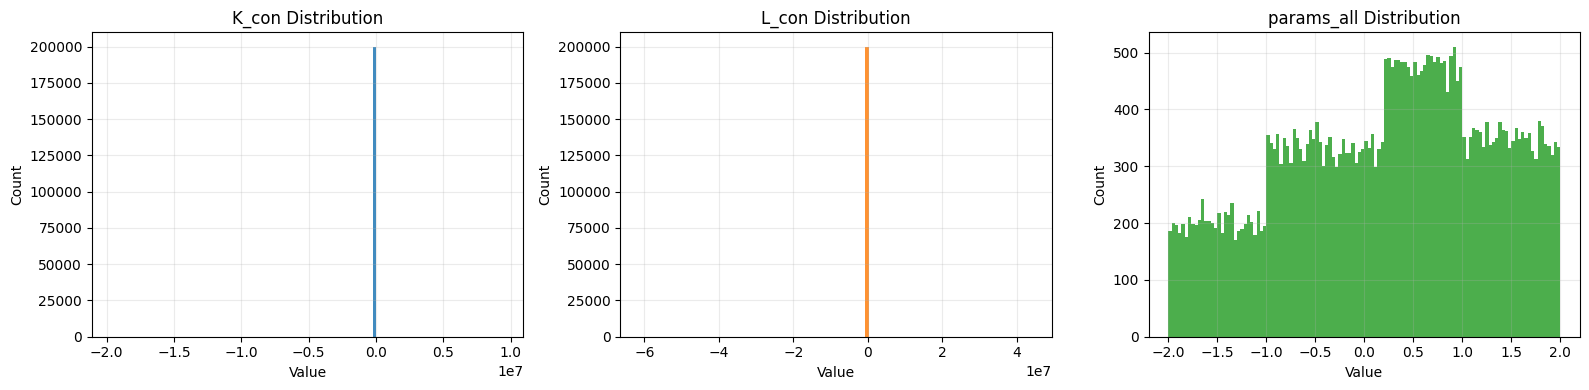

In [16]:
# 17_04 数据分布统计：K_con / L_con / params_all
import numpy as np
import matplotlib.pyplot as plt

# 优先使用已存在变量；如果不存在则从 data_17_04 中取
if 'K_con' in globals() and isinstance(K_con, np.ndarray):
    k_arr = K_con
else:
    k_arr = np.asarray(data_17_04['K_con'])

if 'L_con' in globals() and isinstance(L_con, np.ndarray):
    l_arr = L_con
else:
    l_arr = np.asarray(data_17_04['L_con'])

if 'params_all' in data_17_04:
    p_arr = np.asarray(data_17_04['params_all'])
elif 'params' in data_17_04:
    p_arr = np.asarray(data_17_04['params'])
else:
    raise KeyError('在 data_17_04 中未找到 params_all（或 params）')

def describe(name, arr):
    x = arr.astype(np.float64).reshape(-1)
    print(f'[{name}] shape={arr.shape}, dtype={arr.dtype}')
    print(f'  min={x.min():.6e}, max={x.max():.6e}, mean={x.mean():.6e}, std={x.std():.6e}')
    print(f'  p1={np.percentile(x,1):.6e}, p50={np.percentile(x,50):.6e}, p99={np.percentile(x,99):.6e}')

print('===== 17_04 数据分布统计 =====')
describe('K_con', k_arr)
describe('L_con', l_arr)
describe('params_all', p_arr)

# 可视化直方图
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(k_arr.reshape(-1), bins=120, color='tab:blue', alpha=0.85)
axes[0].set_title('K_con Distribution')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Count')
axes[0].grid(alpha=0.25)

axes[1].hist(l_arr.reshape(-1), bins=120, color='tab:orange', alpha=0.85)
axes[1].set_title('L_con Distribution')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Count')
axes[1].grid(alpha=0.25)

axes[2].hist(p_arr.reshape(-1), bins=120, color='tab:green', alpha=0.85)
axes[2].set_title('params_all Distribution')
axes[2].set_xlabel('Value')
axes[2].set_ylabel('Count')
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

Loading: /home/curry/Documents/NO4Jean/params_and_kernels_22_04.mat
===== 22_04 数据分布统计 =====
[K_con] shape=(25, 2, 2, 3000), dtype=float64
  min=-9.793460e+07, max=4.631901e+08, mean=5.291537e+03, std=1.141072e+06
  p1=-3.628909e+01, p50=4.881174e-03, p99=3.055226e+01
[L_con] shape=(25, 2, 2, 3000), dtype=float64
  min=-9.195106e+08, max=3.978904e+09, mean=4.007639e+04, std=1.171654e+07
  p1=-9.953932e+01, p50=-2.244616e-02, p99=5.765860e+01
[params_all] shape=(3000, 20), dtype=float64
  min=-1.999956e+00, max=1.999891e+00, mean=2.155162e-01, std=1.056397e+00
  p1=-1.933935e+00, p50=3.296215e-01, p99=1.963967e+00


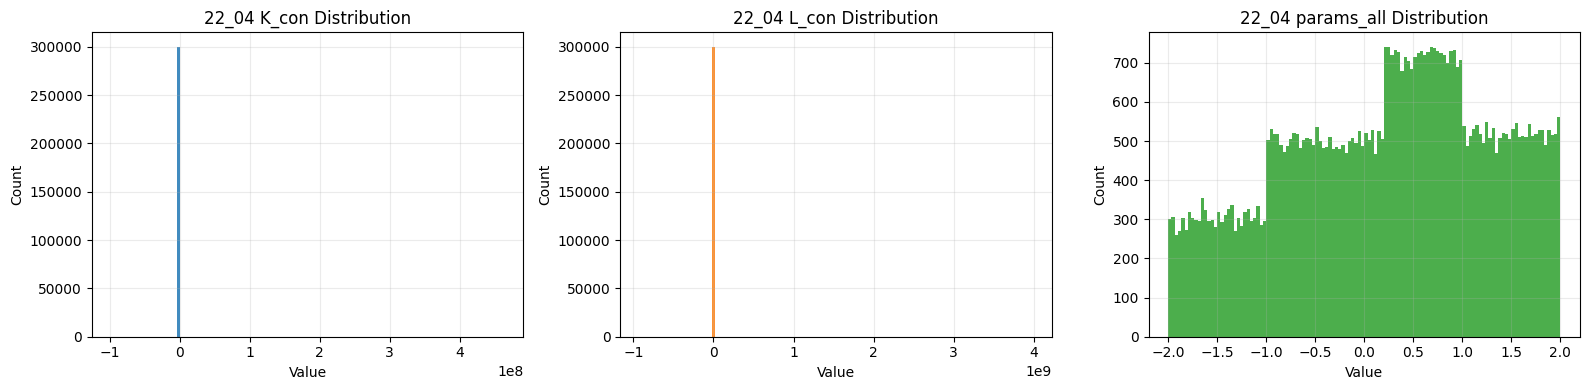

In [17]:
# 22_04 数据分布统计：K_con / L_con / params_all
import numpy as np
import matplotlib.pyplot as plt

file_22_path = BASE_DIR / 'params_and_kernels_22_04.mat'
print(f'Loading: {file_22_path}')

data_22_04 = safe_loadmat(file_22_path)
if data_22_04 is None:
    raise RuntimeError('Failed to load params_and_kernels_22_04.mat')

# Extract arrays
if 'K_con' in data_22_04:
    k22_arr = np.asarray(data_22_04['K_con'])
else:
    raise KeyError('在 22_04 数据中未找到 K_con')

if 'L_con' in data_22_04:
    l22_arr = np.asarray(data_22_04['L_con'])
else:
    raise KeyError('在 22_04 数据中未找到 L_con')

if 'params_all' in data_22_04:
    p22_arr = np.asarray(data_22_04['params_all'])
elif 'params' in data_22_04:
    p22_arr = np.asarray(data_22_04['params'])
else:
    raise KeyError('在 22_04 数据中未找到 params_all（或 params）')


def describe_22(name, arr):
    x = arr.astype(np.float64).reshape(-1)
    print(f'[{name}] shape={arr.shape}, dtype={arr.dtype}')
    print(f'  min={x.min():.6e}, max={x.max():.6e}, mean={x.mean():.6e}, std={x.std():.6e}')
    print(f'  p1={np.percentile(x,1):.6e}, p50={np.percentile(x,50):.6e}, p99={np.percentile(x,99):.6e}')

print('===== 22_04 数据分布统计 =====')
describe_22('K_con', k22_arr)
describe_22('L_con', l22_arr)
describe_22('params_all', p22_arr)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(k22_arr.reshape(-1), bins=120, color='tab:blue', alpha=0.85)
axes[0].set_title('22_04 K_con Distribution')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Count')
axes[0].grid(alpha=0.25)

axes[1].hist(l22_arr.reshape(-1), bins=120, color='tab:orange', alpha=0.85)
axes[1].set_title('22_04 L_con Distribution')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Count')
axes[1].grid(alpha=0.25)

axes[2].hist(p22_arr.reshape(-1), bins=120, color='tab:green', alpha=0.85)
axes[2].set_title('22_04 params_all Distribution')
axes[2].set_xlabel('Value')
axes[2].set_ylabel('Count')
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
# 23_04 数据分布统计：K_con / L_con / params_all
import numpy as np
import matplotlib.pyplot as plt

file_23_path = BASE_DIR / 'params_and_kernels_23_04.mat'
print(f'Loading: {file_23_path}')

data_23_04 = safe_loadmat(file_23_path)
if data_23_04 is None:
    raise RuntimeError('Failed to load params_and_kernels_23_04.mat')

# Extract arrays
if 'K_con' in data_23_04:
    k23_arr = np.asarray(data_23_04['K_con'])
else:
    raise KeyError('在 23_04 数据中未找到 K_con')

if 'L_con' in data_23_04:
    l23_arr = np.asarray(data_23_04['L_con'])
else:
    raise KeyError('在 23_04 数据中未找到 L_con')

if 'params_all' in data_23_04:
    p23_arr = np.asarray(data_23_04['params_all'])
elif 'params' in data_23_04:
    p23_arr = np.asarray(data_23_04['params'])
else:
    raise KeyError('在 23_04 数据中未找到 params_all（或 params）')


def describe_23(name, arr):
    x = arr.astype(np.float64).reshape(-1)
    print(f'[{name}] shape={arr.shape}, dtype={arr.dtype}')
    print(f'  min={x.min():.6e}, max={x.max():.6e}, mean={x.mean():.6e}, std={x.std():.6e}')
    print(f'  p1={np.percentile(x,1):.6e}, p50={np.percentile(x,50):.6e}, p99={np.percentile(x,99):.6e}')

print('===== 23_04 数据分布统计 =====')
describe_23('K_con', k23_arr)
describe_23('L_con', l23_arr)
describe_23('params_all', p23_arr)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(k23_arr.reshape(-1), bins=120, color='tab:blue', alpha=0.85)
axes[0].set_title('23_04 K_con Distribution')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Count')
axes[0].grid(alpha=0.25)

axes[1].hist(l23_arr.reshape(-1), bins=120, color='tab:orange', alpha=0.85)
axes[1].set_title('23_04 L_con Distribution')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Count')
axes[1].grid(alpha=0.25)

axes[2].hist(p23_arr.reshape(-1), bins=120, color='tab:green', alpha=0.85)
axes[2].set_title('23_04 params_all Distribution')
axes[2].set_xlabel('Value')
axes[2].set_ylabel('Count')
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [15]:

# ========================================================================
# Save Training and Test Datasets
# ========================================================================

import os

# Create a datasets directory if it doesn't exist
dataset_dir = BASE_DIR / 'datasets'
dataset_dir.mkdir(exist_ok=True)

# Save using numpy's .npz format (compressed)
train_path = dataset_dir / 'train_data.npz'
test_path = dataset_dir / 'test_data.npz'

np.savez_compressed(train_path, X=X_train, Y=Y_train)
np.savez_compressed(test_path, X=X_test, Y=Y_test)

print('Training and test datasets saved:')
print(f'✓ {train_path}')
print(f'✓ {test_path}')

# Also save metadata for reference
metadata_path = dataset_dir / 'dataset_info.txt'
with open(metadata_path, 'w') as f:
    f.write('Dataset Information\n')
    f.write('=' * 60 + '\n\n')
    f.write('Source: params_and_kernels_17_04.mat\n\n')
    f.write('Training Set:\n')
    f.write(f'  X_train shape: {X_train.shape} (samples, input_dim)\n')
    f.write(f'  Y_train shape: {Y_train.shape} (samples, output_dim)\n')
    f.write(f'  File: train_data.npz\n\n')
    f.write('Test Set:\n')
    f.write(f'  X_test shape: {X_test.shape} (samples, input_dim)\n')
    f.write(f'  Y_test shape: {Y_test.shape} (samples, output_dim)\n')
    f.write(f'  File: test_data.npz\n\n')
    f.write('Output Composition:\n')
    f.write('  First 100 dims: K_con flattened (25*2*2)\n')
    f.write('  Last 100 dims: L_con flattened (25*2*2)\n')
    f.write('  Total output dims: 200\n\n')
    f.write('Train/Test Split: 80% train, 20% test\n')
    f.write('Random Seed: 42 (reproducible)\n')

print(f'✓ {metadata_path}')

# Verify the saved files can be loaded
print('\nVerifying saved datasets:')
train_loaded = np.load(train_path)
test_loaded = np.load(test_path)
print(f'  train_data.npz keys: {list(train_loaded.keys())}')
print(f'  test_data.npz keys: {list(test_loaded.keys())}')
print('\n✓ All datasets saved and verified successfully!')


Training and test datasets saved:
✓ /home/curry/Documents/NO4Jean/datasets/train_data.npz
✓ /home/curry/Documents/NO4Jean/datasets/test_data.npz
✓ /home/curry/Documents/NO4Jean/datasets/dataset_info.txt

Verifying saved datasets:
  train_data.npz keys: ['X', 'Y']
  test_data.npz keys: ['X', 'Y']

✓ All datasets saved and verified successfully!
